In [1]:
# Importaciones estándar del curso
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
from scipy.optimize import fsolve

---

## 📊 EJERCICIO 1: DERIVADAS Y OPTIMIZACIÓN

**Contexto:** Analizar función de demanda cuadrática

**Función:** Qd(p) = 180 - p² - 3p

### ✅ Paso 1: Definir función y calcular derivadas

In [2]:
# Definir variable simbólica
p = sp.Symbol('p')

# Función de demanda
Qd = 180 - p**2 - 3*p
print(f"Función de demanda: Qd(p) = {Qd}")

# Primera derivada
dQd_dp = sp.diff(Qd, p)
print(f"\nPrimera derivada: dQd/dp = {dQd_dp}")

# Segunda derivada
d2Qd_dp2 = sp.diff(dQd_dp, p)
print(f"Segunda derivada: d²Qd/dp² = {d2Qd_dp2}")

# Tercera derivada
d3Qd_dp3 = sp.diff(d2Qd_dp2, p)
print(f"Tercera derivada: d³Qd/dp³ = {d3Qd_dp3}")

print("\n✅ La derivada de mayor orden no nula es la SEGUNDA DERIVADA = -2")
print("La tercera derivada y superiores son nulas porque es una función cuadrática.")

Función de demanda: Qd(p) = -p**2 - 3*p + 180

Primera derivada: dQd/dp = -2*p - 3
Segunda derivada: d²Qd/dp² = -2
Tercera derivada: d³Qd/dp³ = 0

✅ La derivada de mayor orden no nula es la SEGUNDA DERIVADA = -2
La tercera derivada y superiores son nulas porque es una función cuadrática.


### ✅ Paso 2: Encontrar puntos críticos y optimizar

In [3]:
# Encontrar puntos críticos (primera derivada = 0)
puntos_criticos = sp.solve(dQd_dp, p)
print(f"Puntos críticos (dQd/dp = 0): p = {puntos_criticos}")

p_critico = float(puntos_criticos[0])
print(f"Punto crítico: p = {p_critico}")

# Evaluar segunda derivada en el punto crítico
segunda_derivada_valor = float(d2Qd_dp2.subs(p, p_critico))
print(f"\nSegunda derivada en p = {p_critico}: {segunda_derivada_valor}")

# Determinar tipo de extremo
if segunda_derivada_valor > 0:
    tipo_extremo = "MÍNIMO"
elif segunda_derivada_valor < 0:
    tipo_extremo = "MÁXIMO"
else:
    tipo_extremo = "PUNTO DE INFLEXIÓN"

print(f"\n✅ La función posee un {tipo_extremo} local en p = {p_critico}")

# Calcular cantidad en el punto crítico
Qd_critica = float(Qd.subs(p, p_critico))
print(f"Cantidad en el máximo: Qd = {Qd_critica:.2f} unidades")

print("\n📊 INTERPRETACIÓN ECONÓMICA:")
print(f"La demanda alcanza su máximo en p = ${p_critico:.1f}, con Qd = {Qd_critica:.1f} unidades.")
print("Esto es económicamente ANÓMALO porque normalmente la demanda disminuye con el precio.")

Puntos críticos (dQd/dp = 0): p = [-3/2]
Punto crítico: p = -1.5

Segunda derivada en p = -1.5: -2.0

✅ La función posee un MÁXIMO local en p = -1.5
Cantidad en el máximo: Qd = 182.25 unidades

📊 INTERPRETACIÓN ECONÓMICA:
La demanda alcanza su máximo en p = $-1.5, con Qd = 182.2 unidades.
Esto es económicamente ANÓMALO porque normalmente la demanda disminuye con el precio.


### ✅ Paso 3: Graficar función y derivadas

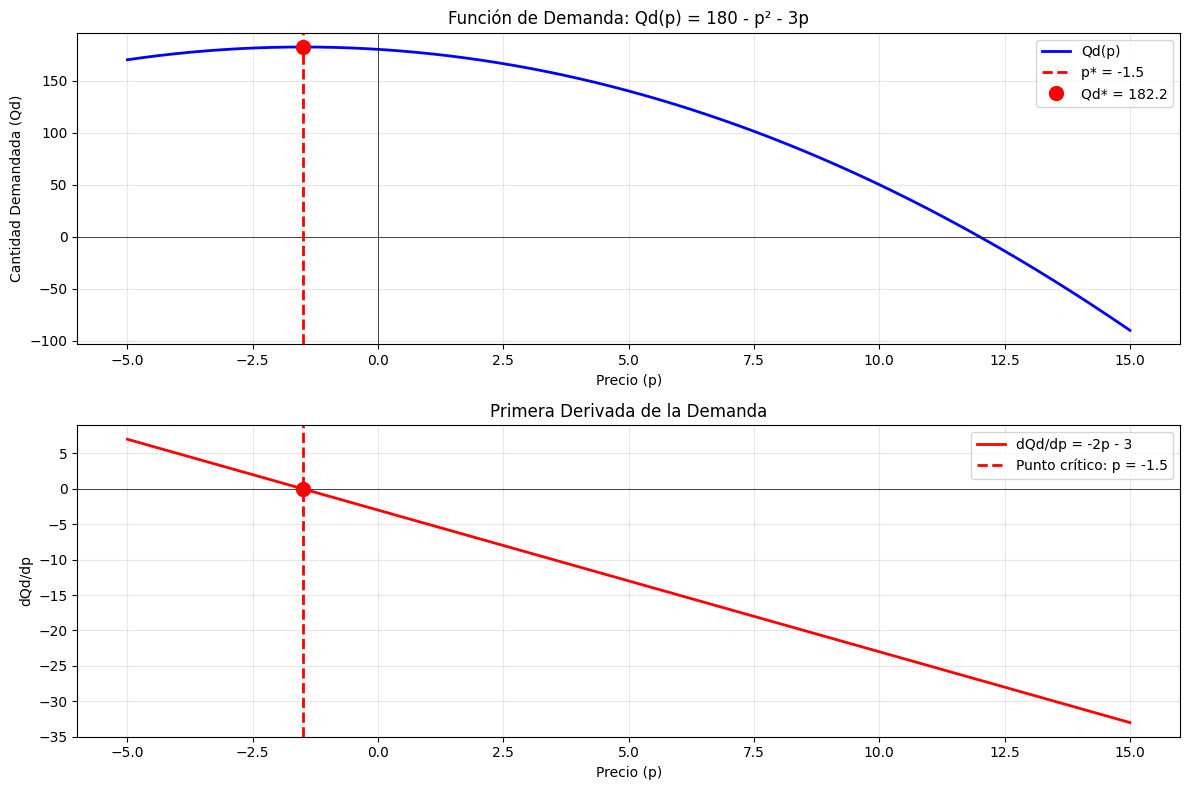

In [4]:
# Convertir a funciones numéricas
Qd_func = sp.lambdify(p, Qd, 'numpy')
dQd_func = sp.lambdify(p, dQd_dp, 'numpy')

# Rango de precios
p_vals = np.linspace(-5, 15, 500)

plt.figure(figsize=(12, 8))

# Subplot 1: Función de demanda
plt.subplot(2, 1, 1)
plt.plot(p_vals, Qd_func(p_vals), 'b-', linewidth=2, label='Qd(p)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.axvline(x=p_critico, color='red', linewidth=2, linestyle='--', label=f'p* = {p_critico:.1f}')
plt.plot(p_critico, Qd_critica, 'ro', markersize=10, label=f'Qd* = {Qd_critica:.1f}')
plt.xlabel('Precio (p)')
plt.ylabel('Cantidad Demandada (Qd)')
plt.title('Función de Demanda: Qd(p) = 180 - p² - 3p')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Primera derivada
plt.subplot(2, 1, 2)
plt.plot(p_vals, dQd_func(p_vals), 'r-', linewidth=2, label="dQd/dp = -2p - 3")
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=p_critico, color='red', linewidth=2, linestyle='--', label=f'Punto crítico: p = {p_critico:.1f}')
plt.plot(p_critico, 0, 'ro', markersize=10)
plt.xlabel('Precio (p)')
plt.ylabel("dQd/dp")
plt.title('Primera Derivada de la Demanda')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 📈 EJERCICIO 2: ELASTICIDAD PRECIO DE LA DEMANDA

**Contexto:** Calcular elasticidad continua y discreta

**Función:** Qd(p) = 180 - p² - 3p

### ✅ Paso 1: Calcular elasticidad continua

In [5]:
# Fórmula de elasticidad precio: ε = (dQd/dp) × (p/Qd)
elasticidad = (dQd_dp * p) / Qd
print("Fórmula de elasticidad: ε = (dQd/dp) × (p/Qd)")
print(f"ε = ({dQd_dp}) × (p/({Qd}))")

# Simplificar la expresión
elasticidad_simplificada = sp.simplify(elasticidad)
print(f"\nElasticidad simplificada: ε = {elasticidad_simplificada}")

# Función numérica para evaluación
def calcular_elasticidad(precio):
    cantidad = 180 - precio**2 - 3*precio
    if cantidad <= 0:
        return float('inf')
    derivada = -2*precio - 3
    return (derivada * precio) / cantidad

def demanda_numerica(precio):
    return 180 - precio**2 - 3*precio

Fórmula de elasticidad: ε = (dQd/dp) × (p/Qd)
ε = (-2*p - 3) × (p/(-p**2 - 3*p + 180))

Elasticidad simplificada: ε = p*(2*p + 3)/(p**2 + 3*p - 180)

Elasticidad simplificada: ε = p*(2*p + 3)/(p**2 + 3*p - 180)


### ✅ Paso 2: Evaluar elasticidades para precios específicos

In [6]:
# Evaluar elasticidades para los precios solicitados
precios_evaluar = [1, 5, 10]

resultados = []
for precio in precios_evaluar:
    cantidad = demanda_numerica(precio)
    elasticidad_val = calcular_elasticidad(precio)
    
    # Clasificar tipo de elasticidad
    if abs(elasticidad_val) > 1:
        tipo = "Elástica"
    elif abs(elasticidad_val) == 1:
        tipo = "Unitaria"
    else:
        tipo = "Inelástica"
    
    resultados.append({
        'Precio (p)': precio,
        'Cantidad (Qd)': round(cantidad, 2),
        'Elasticidad (ε)': round(elasticidad_val, 3),
        'Tipo': tipo
    })
    
    print(f"\n📊 Para p = ${precio}:")
    print(f"   Cantidad demandada: {cantidad:.2f} unidades")
    print(f"   Elasticidad: {elasticidad_val:.3f}")
    print(f"   Tipo: {tipo}")
    
    if elasticidad_val > 0:
        print("   ⚠️ ANOMALÍA: Elasticidad positiva indica bien Giffen o Veblen")

# Crear DataFrame con resultados
df_elasticidades = pd.DataFrame(resultados)
print("\n📋 RESUMEN DE ELASTICIDADES:")
print(df_elasticidades.to_string(index=False))


📊 Para p = $1:
   Cantidad demandada: 176.00 unidades
   Elasticidad: -0.028
   Tipo: Inelástica

📊 Para p = $5:
   Cantidad demandada: 140.00 unidades
   Elasticidad: -0.464
   Tipo: Inelástica

📊 Para p = $10:
   Cantidad demandada: 50.00 unidades
   Elasticidad: -4.600
   Tipo: Elástica

📋 RESUMEN DE ELASTICIDADES:
 Precio (p)  Cantidad (Qd)  Elasticidad (ε)       Tipo
          1            176           -0.028 Inelástica
          5            140           -0.464 Inelástica
         10             50           -4.600   Elástica


### ✅ Paso 3: Comparar elasticidad continua vs discreta

In [7]:
print("🔍 ANÁLISIS: ELASTICIDAD CONTINUA vs DISCRETA")
print("=" * 50)

# Ejemplo práctico: comparar entre p=$4 y p=$6
p1, p2 = 4, 6
q1 = demanda_numerica(p1)
q2 = demanda_numerica(p2)

# Método del punto medio (más preciso)
delta_q = q2 - q1
delta_p = p2 - p1
q_promedio = (q1 + q2) / 2
p_promedio = (p1 + p2) / 2

elasticidad_discreta = (delta_q / q_promedio) / (delta_p / p_promedio)

# Elasticidad continua en el punto medio
elasticidad_continua_medio = calcular_elasticidad(p_promedio)

print(f"\nEntre p=${p1} y p=${p2}:")
print(f"  Q1 = {q1:.2f}, Q2 = {q2:.2f}")
print(f"  ΔQ = {delta_q:.2f}, Δp = {delta_p:.2f}")
print(f"\n✅ Elasticidad DISCRETA (arco): {elasticidad_discreta:.3f}")
print(f"✅ Elasticidad CONTINUA en p=${p_promedio}: {elasticidad_continua_medio:.3f}")
print(f"\nDiferencia: {abs(elasticidad_discreta - elasticidad_continua_medio):.3f}")

🔍 ANÁLISIS: ELASTICIDAD CONTINUA vs DISCRETA

Entre p=$4 y p=$6:
  Q1 = 152.00, Q2 = 126.00
  ΔQ = -26.00, Δp = 2.00

✅ Elasticidad DISCRETA (arco): -0.468
✅ Elasticidad CONTINUA en p=$5.0: -0.464

Diferencia: 0.003


---

## 💰 EJERCICIO 3: MAXIMIZACIÓN DE BENEFICIO EN MONOPOLIO

**Contexto:** Monopolio con demanda inversa y costo

**Demanda inversa:** p(q) = 500 - 0.5q - 0.002q²

**Costo total:** C(q) = 300 + 8q + 0.05q²

### ✅ Paso 1: Definir funciones del monopolio

In [8]:
# Definir variable simbólica
q = sp.Symbol('q', positive=True)

# Función de demanda inversa
p_demanda = 500 - sp.Rational(1,2)*q - sp.Rational(2,1000)*q**2
print(f"Demanda inversa: p(q) = {p_demanda}")

# Función de costo total
C = 300 + 8*q + sp.Rational(5,100)*q**2
print(f"Costo total: C(q) = {C}")

Demanda inversa: p(q) = -q**2/500 - q/2 + 500
Costo total: C(q) = q**2/20 + 8*q + 300


### ✅ Paso 2: Definir ingreso total y beneficio

In [9]:
# Ingreso Total: IT = p × q
IT = p_demanda * q
IT_expandido = sp.expand(IT)
print(f"Ingreso Total: IT = {IT_expandido}")

# Beneficio: Π = IT - CT
beneficio = IT - C
beneficio_expandido = sp.expand(beneficio)
print(f"Beneficio: Π = {beneficio_expandido}")

Ingreso Total: IT = -q**3/500 - q**2/2 + 500*q
Beneficio: Π = -q**3/500 - 11*q**2/20 + 492*q - 300


### ✅ Paso 3: Encontrar cantidad óptima (CPO y CSO)

In [10]:
# Condición de Primer Orden (CPO): dΠ/dq = 0
d_beneficio_dq = sp.diff(beneficio, q)
print(f"Condición de Primer Orden:")
print(f"dΠ/dq = {d_beneficio_dq}")

# Resolver para q
q_optimo_simbolico = sp.solve(d_beneficio_dq, q)
print(f"\nCantidades críticas: {q_optimo_simbolico}")

# Condición de Segundo Orden (CSO): d²Π/dq² < 0 para máximo
d2_beneficio_dq2 = sp.diff(beneficio, q, 2)
print(f"\nCondición de Segundo Orden:")
print(f"d²Π/dq² = {d2_beneficio_dq2}")

# Verificar cuál es el máximo
for q_cand in q_optimo_simbolico:
    if q_cand.is_real and q_cand > 0:
        cso_valor = d2_beneficio_dq2.subs(q, q_cand)
        
        print(f"\nPara q = {q_cand}:")
        print(f"   d²Π/dq² = {cso_valor}")
        
        if cso_valor < 0:
            print(f"   ✓ Es un MÁXIMO (CSO < 0)")
            q_optimo = q_cand
        elif cso_valor > 0:
            print(f"   ✗ Es un MÍNIMO (CSO > 0)")
        else:
            print(f"   ? Indeterminado (CSO = 0)")

Condición de Primer Orden:
dΠ/dq = -q**2/500 + q*(-q/250 - 1/2) - 3*q/5 + 492

Cantidades críticas: [-275/3 + 5*sqrt(32545)/3]

Condición de Segundo Orden:
d²Π/dq² = -(3*q + 275)/250

Para q = -275/3 + 5*sqrt(32545)/3:
   d²Π/dq² = -sqrt(32545)/50
   ✓ Es un MÁXIMO (CSO < 0)

Cantidades críticas: [-275/3 + 5*sqrt(32545)/3]

Condición de Segundo Orden:
d²Π/dq² = -(3*q + 275)/250

Para q = -275/3 + 5*sqrt(32545)/3:
   d²Π/dq² = -sqrt(32545)/50
   ✓ Es un MÁXIMO (CSO < 0)


### ✅ Paso 4: Calcular resultados en el óptimo

In [11]:
# Evaluar todas las variables en el óptimo
q_opt = float(q_optimo.evalf())
p_opt = float(p_demanda.subs(q, q_optimo).evalf())
IT_opt = float(IT.subs(q, q_optimo).evalf())
C_opt = float(C.subs(q, q_optimo).evalf())
beneficio_opt = float(beneficio.subs(q, q_optimo).evalf())

print("\n📊 RESULTADOS ÓPTIMOS DEL MONOPOLIO:")
print("="*50)
print(f"   Cantidad óptima: q* = {q_opt:.2f} unidades")
print(f"   Precio óptimo: p* = ${p_opt:.2f}")
print(f"   Ingreso Total: IT* = ${IT_opt:.2f}")
print(f"   Costo Total: C* = ${C_opt:.2f}")
print(f"   Beneficio Máximo: Π* = ${beneficio_opt:.2f}")


📊 RESULTADOS ÓPTIMOS DEL MONOPOLIO:
   Cantidad óptima: q* = 209.00 unidades
   Precio óptimo: p* = $308.13
   Ingreso Total: IT* = $64400.95
   Costo Total: C* = $4156.16
   Beneficio Máximo: Π* = $60244.79


### ✅ Paso 5: Verificar IM = CM

In [12]:
# Ingreso Marginal
IM = sp.diff(IT, q)
IM_opt = float(IM.subs(q, q_optimo).evalf())

# Costo Marginal
CM = sp.diff(C, q)
CM_opt = float(CM.subs(q, q_optimo).evalf())

print("\nVerificación de la condición de equilibrio:")
print("="*50)
print(f"Ingreso Marginal (IM): {IM}")
print(f"Costo Marginal (CM): {CM}")
print(f"\nEn el punto óptimo q* = {q_opt:.2f}:")
print(f"   IM = ${IM_opt:.2f}")
print(f"   CM = ${CM_opt:.2f}")
print(f"   Diferencia: ${abs(IM_opt - CM_opt):.4f}")

if abs(IM_opt - CM_opt) < 0.01:
    print("\n✅ Se cumple la condición IM = CM")


Verificación de la condición de equilibrio:
Ingreso Marginal (IM): -q**2/500 + q*(-q/250 - 1/2) - q/2 + 500
Costo Marginal (CM): q/10 + 8

En el punto óptimo q* = 209.00:
   IM = $28.90
   CM = $28.90
   Diferencia: $0.0000

✅ Se cumple la condición IM = CM


### ✅ Paso 6: Visualización gráfica

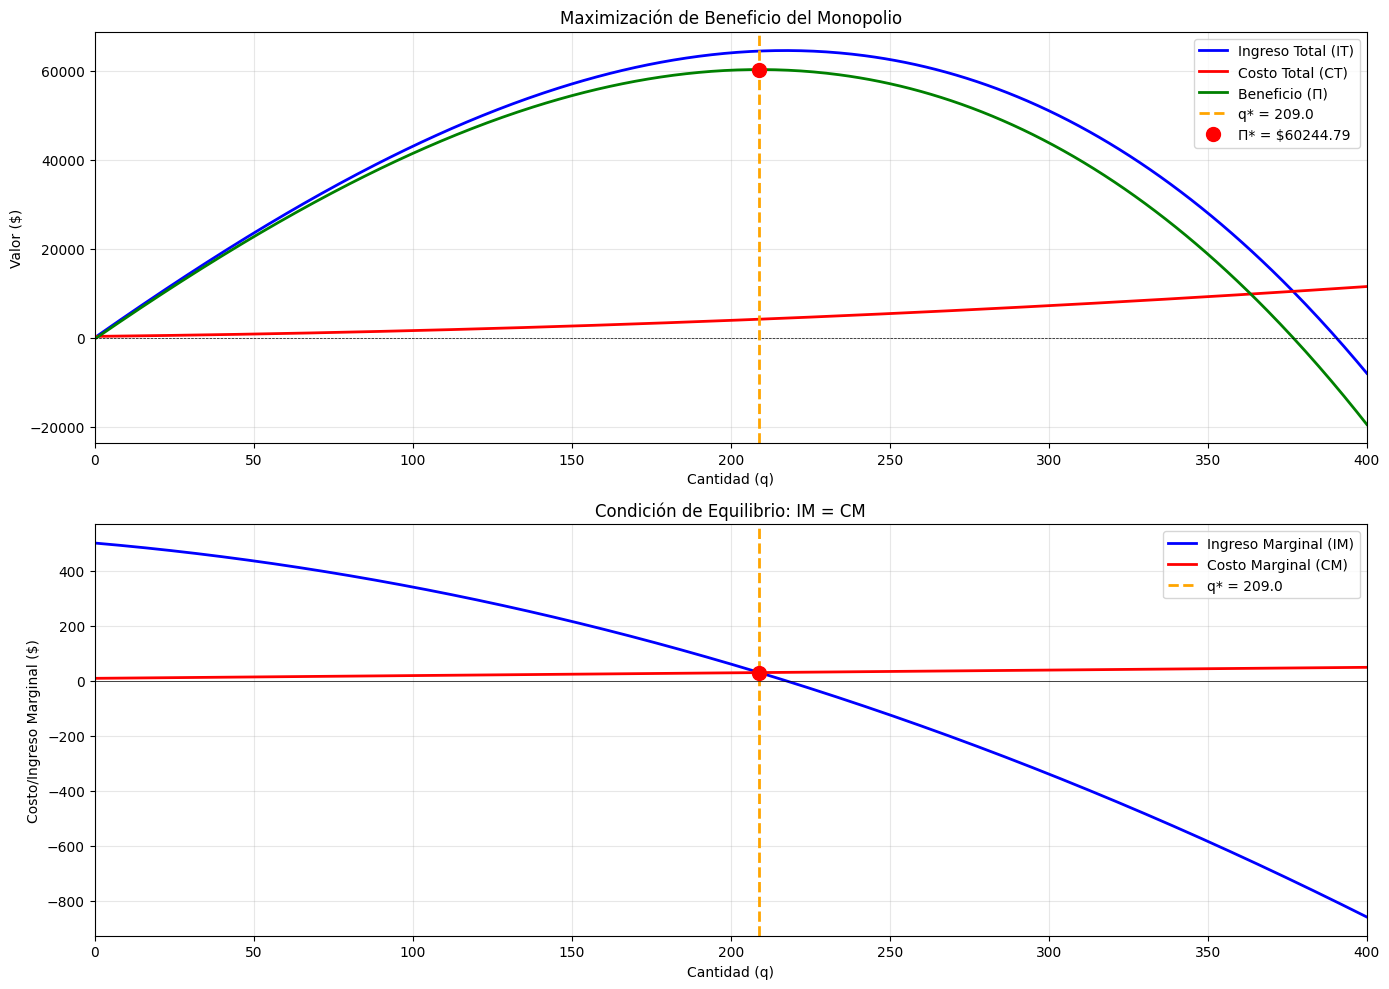

In [24]:
# Convertir a funciones numéricas
IT_func = sp.lambdify(q, IT, 'numpy')
C_func = sp.lambdify(q, C, 'numpy')
beneficio_func = sp.lambdify(q, beneficio, 'numpy')
IM_func = sp.lambdify(q, IM, 'numpy')
CM_func = sp.lambdify(q, CM, 'numpy')

# Rango de cantidades
q_vals = np.linspace(0, 400, 500)

plt.figure(figsize=(14, 10))

# Subplot 1: IT, CT, Beneficio
plt.subplot(2, 1, 1)
plt.plot(q_vals, IT_func(q_vals), 'b-', linewidth=2, label='Ingreso Total (IT)')
plt.plot(q_vals, C_func(q_vals), 'r-', linewidth=2, label='Costo Total (CT)')
plt.plot(q_vals, beneficio_func(q_vals), 'g-', linewidth=2, label='Beneficio (Π)')
plt.axhline(y=0, color='k', linewidth=0.5, linestyle='--')
plt.axvline(x=q_opt, color='orange', linewidth=2, linestyle='--', label=f'q* = {q_opt:.1f}')
plt.plot(q_opt, beneficio_opt, 'ro', markersize=10, label=f'Π* = ${beneficio_opt:.2f}')
plt.xlabel('Cantidad (q)')
plt.ylabel('Valor ($)')
plt.title('Maximización de Beneficio del Monopolio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 400)

# Subplot 2: IM y CM
plt.subplot(2, 1, 2)
plt.plot(q_vals, IM_func(q_vals), 'b-', linewidth=2, label='Ingreso Marginal (IM)')
plt.plot(q_vals, CM_func(q_vals), 'r-', linewidth=2, label='Costo Marginal (CM)')
plt.axvline(x=q_opt, color='orange', linewidth=2, linestyle='--', label=f'q* = {q_opt:.1f}')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.plot(q_opt, IM_opt, 'ro', markersize=10)
plt.xlabel('Cantidad (q)')
plt.ylabel('Costo/Ingreso Marginal ($)')
plt.title('Condición de Equilibrio: IM = CM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 400)

plt.tight_layout()
plt.show()

---

## 📝 RESUMEN DE MÉTODOS CLAVE

### **Derivadas con SymPy:**
1. Definir variables: `x = sp.Symbol('x')`
2. Definir función: `f = x**2 + 3*x`
3. Derivar: `df = sp.diff(f, x)` o `sp.diff(f, x, n)` para n-ésima
4. Evaluar: `df.subs(x, valor).evalf()`
5. Convertir a numérica: `sp.lambdify(x, f, 'numpy')`

### **Optimización:**
1. CPO: `sp.solve(df, x)` donde `df = sp.diff(f, x)`
2. CSO: Evaluar `sp.diff(f, x, 2)` en puntos críticos
3. Si CSO < 0 → máximo, si CSO > 0 → mínimo

### **Elasticidad:**
- Continua: `ε = (dQd/dp) × (p/Qd)`
- Discreta: `ε = (ΔQ/Q_prom) / (Δp/p_prom)`
- |ε| > 1: elástica, |ε| = 1: unitaria, |ε| < 1: inelástica

### **Monopolio:**
1. IT = p(q) × q
2. Π = IT - C
3. CPO: dΠ/dq = 0 → IM = CM
4. CSO: d²Π/dq² < 0

---

## ✅ CHECKLIST PARA EL EXAMEN

**Antes de entregar:**
- [ ] Todas las variables simbólicas definidas con `sp.Symbol()`
- [ ] Derivadas calculadas con `sp.diff()`
- [ ] Puntos críticos encontrados con `sp.solve()`
- [ ] Segunda derivada evaluada (CSO)
- [ ] Resultados numéricos con `.evalf()`
- [ ] Interpretación económica incluida
- [ ] Gráficos con títulos y etiquetas en español
- [ ] Verificación de condiciones (IM=CM, etc.)
- [ ] Solo métodos enseñados por el profesor
- [ ] Código comentado claramente